In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Loading dataset
data = sns.load_dataset('tips')


In [3]:
data.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Find The Total Bill (predicton)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [5]:
data['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [6]:
X = data.drop('total_bill',axis=1)
y = data['total_bill']


In [7]:
y

0      16.99
1      10.34
2      21.01
3      23.68
4      24.59
       ...  
239    29.03
240    27.18
241    22.67
242    17.82
243    18.78
Name: total_bill, Length: 244, dtype: float64

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25)

In [9]:
X_train

,tip,sex,smoker,day,time,size
104,4.08,Female,No,Sat,Dinner,2
116,5.07,Male,No,Sun,Dinner,4
206,3.41,Male,Yes,Sat,Dinner,3
194,4.00,Male,Yes,Thur,Lunch,2
60,3.21,Male,Yes,Sat,Dinner,2
...,...,...,...,...,...,...
205,3.23,Female,Yes,Thur,Lunch,3
80,3.00,Male,Yes,Thur,Lunch,2
39,5.00,Male,No,Sat,Dinner,3
238,4.67,Female,No,Sat,Dinner,3


In [10]:
day = pd.get_dummies(X_train['day'])
X_train.drop('day',axis=1,inplace=True)

X_train = pd.concat([X_train,day],axis=1)

In [11]:
X_train

,tip,sex,smoker,time,size,Thur,Fri,Sat,Sun
104,4.08,Female,No,Dinner,2,False,False,True,False
116,5.07,Male,No,Dinner,4,False,False,False,True
206,3.41,Male,Yes,Dinner,3,False,False,True,False
194,4.00,Male,Yes,Lunch,2,True,False,False,False
60,3.21,Male,Yes,Dinner,2,False,False,True,False
...,...,...,...,...,...,...,...,...,...
205,3.23,Female,Yes,Lunch,3,True,False,False,False
80,3.00,Male,Yes,Lunch,2,True,False,False,False
39,5.00,Male,No,Dinner,3,False,False,True,False
238,4.67,Female,No,Dinner,3,False,False,True,False


In [12]:
sex = pd.get_dummies(X_train['sex'])
X_train.drop('sex',axis=1,inplace=True)
X_train = pd.concat([X_train,sex], axis=1)

In [13]:
time = pd.get_dummies(X_train['time'])
X_train.drop('time',axis=1,inplace=True)
X_train = pd.concat([X_train,time], axis=1)

In [14]:
X_train

,tip,smoker,size,Thur,Fri,Sat,Sun,Male,Female,Lunch,Dinner
104,4.08,No,2,False,False,True,False,False,True,False,True
116,5.07,No,4,False,False,False,True,True,False,False,True
206,3.41,Yes,3,False,False,True,False,True,False,False,True
194,4.00,Yes,2,True,False,False,False,True,False,True,False
60,3.21,Yes,2,False,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
205,3.23,Yes,3,True,False,False,False,False,True,True,False
80,3.00,Yes,2,True,False,False,False,True,False,True,False
39,5.00,No,3,False,False,True,False,True,False,False,True
238,4.67,No,3,False,False,True,False,False,True,False,True


In [15]:
smoker = pd.get_dummies(X_train['smoker'])
X_train.drop('smoker',axis=1,inplace=True)
X_train = pd.concat([X_train,smoker],axis=1)

In [16]:
X_train

,tip,size,Thur,Fri,Sat,Sun,Male,Female,Lunch,Dinner,Yes,No
104,4.08,2,False,False,True,False,False,True,False,True,False,True
116,5.07,4,False,False,False,True,True,False,False,True,False,True
206,3.41,3,False,False,True,False,True,False,False,True,True,False
194,4.00,2,True,False,False,False,True,False,True,False,True,False
60,3.21,2,False,False,True,False,True,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
205,3.23,3,True,False,False,False,False,True,True,False,True,False
80,3.00,2,True,False,False,False,True,False,True,False,True,False
39,5.00,3,False,False,True,False,True,False,False,True,False,True
238,4.67,3,False,False,True,False,False,True,False,True,False,True


In [17]:
from sklearn.svm import SVR

In [18]:
model = SVR()

In [19]:
model.fit(X_train,y_train)

SVR()

In [20]:
## again, remove data form X_test that have categorical data 

In [21]:
X_test

,tip,sex,smoker,day,time,size
154,2.00,Male,No,Sun,Dinner,4
218,1.44,Male,Yes,Sat,Dinner,2
127,2.00,Female,No,Thur,Lunch,2
134,3.25,Female,No,Thur,Lunch,2
47,6.00,Male,No,Sun,Dinner,4
...,...,...,...,...,...,...
2,3.50,Male,No,Sun,Dinner,3
1,1.66,Male,No,Sun,Dinner,3
102,2.50,Female,Yes,Sat,Dinner,3
79,2.71,Male,No,Thur,Lunch,2


In [22]:
day = pd.get_dummies(X_test['day'])
X_test.drop('day',axis=1,inplace=True)
X_test = pd.concat([X_test,day],axis=1)
X_test

,tip,sex,smoker,time,size,Thur,Fri,Sat,Sun
154,2.00,Male,No,Dinner,4,False,False,False,True
218,1.44,Male,Yes,Dinner,2,False,False,True,False
127,2.00,Female,No,Lunch,2,True,False,False,False
134,3.25,Female,No,Lunch,2,True,False,False,False
47,6.00,Male,No,Dinner,4,False,False,False,True
...,...,...,...,...,...,...,...,...,...
2,3.50,Male,No,Dinner,3,False,False,False,True
1,1.66,Male,No,Dinner,3,False,False,False,True
102,2.50,Female,Yes,Dinner,3,False,False,True,False
79,2.71,Male,No,Lunch,2,True,False,False,False


In [23]:
sex = pd.get_dummies(X_test['sex'])
X_test.drop('sex',axis=1,inplace=True)
X_test = pd.concat([X_test,sex],axis=1)
X_test

,tip,smoker,time,size,Thur,Fri,Sat,Sun,Male,Female
154,2.00,No,Dinner,4,False,False,False,True,True,False
218,1.44,Yes,Dinner,2,False,False,True,False,True,False
127,2.00,No,Lunch,2,True,False,False,False,False,True
134,3.25,No,Lunch,2,True,False,False,False,False,True
47,6.00,No,Dinner,4,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...
2,3.50,No,Dinner,3,False,False,False,True,True,False
1,1.66,No,Dinner,3,False,False,False,True,True,False
102,2.50,Yes,Dinner,3,False,False,True,False,False,True
79,2.71,No,Lunch,2,True,False,False,False,True,False


In [24]:
time = pd.get_dummies(X_test['time'])
X_test.drop('time',axis=1,inplace=True)
X_test = pd.concat([X_test,time],axis=1)
X_test

,tip,smoker,size,Thur,Fri,Sat,Sun,Male,Female,Lunch,Dinner
154,2.00,No,4,False,False,False,True,True,False,False,True
218,1.44,Yes,2,False,False,True,False,True,False,False,True
127,2.00,No,2,True,False,False,False,False,True,True,False
134,3.25,No,2,True,False,False,False,False,True,True,False
47,6.00,No,4,False,False,False,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
2,3.50,No,3,False,False,False,True,True,False,False,True
1,1.66,No,3,False,False,False,True,True,False,False,True
102,2.50,Yes,3,False,False,True,False,False,True,False,True
79,2.71,No,2,True,False,False,False,True,False,True,False


In [25]:
smoker = pd.get_dummies(X_test['smoker'])
X_test.drop('smoker',axis=1,inplace=True)
X_test = pd.concat([X_test,smoker],axis=1)
X_test

,tip,size,Thur,Fri,Sat,Sun,Male,Female,Lunch,Dinner,Yes,No
154,2.00,4,False,False,False,True,True,False,False,True,False,True
218,1.44,2,False,False,True,False,True,False,False,True,True,False
127,2.00,2,True,False,False,False,False,True,True,False,False,True
134,3.25,2,True,False,False,False,False,True,True,False,False,True
47,6.00,4,False,False,False,True,True,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
2,3.50,3,False,False,False,True,True,False,False,True,False,True
1,1.66,3,False,False,False,True,True,False,False,True,False,True
102,2.50,3,False,False,True,False,False,True,False,True,True,False
79,2.71,2,True,False,False,False,True,False,True,False,False,True


In [32]:
prdictions = model.predict(X_test)
prdictions


array([19.31776177, 14.01958854, 12.7333288 , 16.52178083, 27.96811004,
       22.06035456, 17.43131868, 12.62689648, 27.16319762, 12.70226208,
       23.007188  , 27.63410047, 17.23320836, 23.43463006, 15.3675137 ,
       19.31776177, 26.34473179, 13.10008323, 26.51577158, 14.3156862 ,
       27.70804286, 17.75160128, 16.72894488, 12.97342412, 24.12659056,
       13.28486695, 12.7333288 , 13.05061356, 26.9140575 , 22.11056403,
       17.3638815 , 13.57411126, 27.75852231, 23.98174801, 18.4728532 ,
       15.67509728, 20.44145503, 14.34673596, 19.39800119, 17.42787362,
       14.92225896, 15.0266147 , 27.14478136, 16.27767679, 14.28842048,
       21.3722073 , 14.45053825, 21.64093899, 14.20203744, 15.0266147 ,
       17.75107227, 13.61689755, 15.49270137, 21.05576588, 11.83504371,
       21.00184627, 21.43702145, 16.17144484, 17.68040896, 15.45882861,
       21.05576588])

In [28]:
## metrics

from sklearn import metrics

In [33]:
# finding error (price is differnce or error upto 100k)
print(np.sqrt(metrics.mean_squared_error(y_test,prdictions)))

7.933507249349322


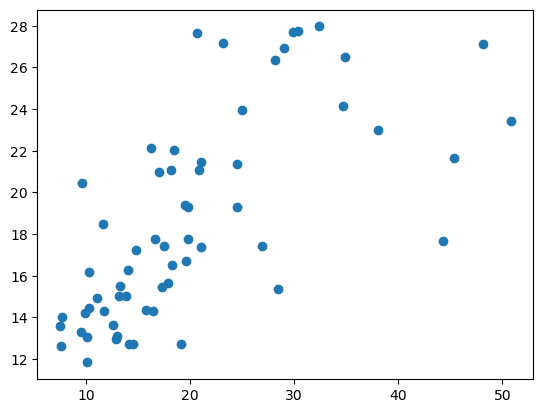

In [36]:

# y_test real value and prdictions(train data)
plt.scatter(y_test,prdictions)